# What is Ensemble Learning?

## Ensemble Learning

**Ensemble Learning** means combining predictions from **multiple models** to get a better and more reliable prediction.

Instead of depending on **one model**, we use **many models** and combine their results.

---

## Simple Example

Suppose we want to predict whether an email is **Spam or Not Spam**.

Three models give predictions:

**Model 1 → Spam**

**Model 2 → Spam**

**Model 3 → Not Spam**

Majority says **Spam**.

Therefore:

**Final Prediction → Spam**

> **Many models → Combine predictions → Better final prediction**

---

## Where is Ensemble Learning Used?

Ensemble Learning can be used in many Machine Learning problems:

- **Classification** → Spam detection, fraud detection
- **Regression** → House price prediction
- **Customer churn prediction**
- **Medical prediction**
- **Credit risk prediction**
- **Recommendation systems**

---

## When Do We Use Ensemble Learning?

We use Ensemble Learning when:

- One model is **not giving good performance**
- We want **better accuracy**
- We want a **more reliable and robust model**
- We want to reduce **overfitting**
- Different models make **different mistakes**

---

## Basic Ensemble Techniques

### 1. Majority Vote

**Majority Vote** is mainly used for **classification**.

Example:

**Model 1 → Spam**

**Model 2 → Spam**

**Model 3 → Not Spam**

Two models say Spam.

Therefore:

**Final Prediction → Spam**

> The class with the **most votes wins**.

---

### 2. Average

**Average** is mainly used for **regression**.

Example:

Three models predict a house price:

**Model 1 → ₹50 lakh**

**Model 2 → ₹55 lakh**

**Model 3 → ₹60 lakh**

Average:

$$
\frac{50 + 55 + 60}{3} = 55
$$

Therefore:

**Final Prediction = ₹55 lakh**

---

### 3. Weighted Average

In a **Weighted Average**, some models are given **more importance** than others.

used in **regression**

Example:

**Model 1 → ₹50 lakh → Weight = 1**

**Model 2 → ₹55 lakh → Weight = 2**

**Model 3 → ₹60 lakh → Weight = 3**

The model with a **higher weight** has more influence on the final prediction.

---

## Advanced Ensemble Techniques - used in both regression and classification

### 1. Bagging

**Bagging = Train multiple models independently and combine their predictions.**

Simple flow:

**Data**

↓

**Decision Tree 1**

**Decision Tree 2**

**Decision Tree 3**

**Decision Tree 4**

**Decision Tree 5**

↓

**Combine Predictions**

↓

**Final Prediction**

### Example

**Random Forest** is a popular Bagging method.

It uses many Decision Trees and combines their predictions.

---

### 2. Boosting

**Boosting = Train models one after another.**

Each new model tries to **improve the mistakes made by the previous models**.

Simple flow:

**Model 1**

↓

**Find mistakes**

↓

**Model 2 focuses more on mistakes**

↓

**Model 3 improves further**

↓

**Combine predictions**

↓

**Final Prediction**

### Examples

- **AdaBoost**
- **Gradient Boosting**
- **XGBoost**
- **LightGBM**
- **CatBoost**

---

### 3. Stacking

**Stacking = Combine different types of models and use another model to make the final prediction.**

Simple flow:

**Input**

↓

**Logistic Regression**

**SVM**

**Decision Tree**

↓

**Their Predictions**

↓

**Final Model (Meta Model)**

↓

**Final Prediction**

The **meta model** learns how to combine the predictions from the other models.

---

## Basic vs Advanced Ensemble Techniques

| Technique | Simple Meaning | Example |
|---|---|---|
| **Majority Vote** | Most common class wins | Spam / Not Spam |
| **Average** | Average the predictions | House price |
| **Weighted Average** | Give some models more importance | House price |
| **Bagging** | Train models independently and combine | Random Forest |
| **Boosting** | Models learn from previous mistakes | XGBoost |
| **Stacking** | Another model combines model predictions | Logistic Regression + SVM + Decision Tree |

---

## Easy Way to Remember

> **Ensemble = Many models working together**

### Bagging

**Models work independently**

### Boosting

**Models work one after another and learn from mistakes**

### Stacking

**Another model combines the predictions**

### In one line:

**Many Models → Combine Predictions → Better Final Prediction**

# Majority Voting, Average and Weighted Average

In [1]:
import pandas as pd
df=pd.read_excel(r"..\Datasets\Raisin_Dataset.xlsx")
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [2]:
x=df.drop("Class",axis=1)
y=df["Class"]

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [3]:
from sklearn.svm import SVC

model=SVC(kernel="rbf")
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

from sklearn.metrics import classification_report 

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       Besni       0.86      0.81      0.83        95
     Kecimen       0.80      0.85      0.82        85

    accuracy                           0.83       180
   macro avg       0.83      0.83      0.83       180
weighted avg       0.83      0.83      0.83       180



In [4]:
from sklearn.ensemble import VotingClassifier
# for regression VotingRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

log_model=LogisticRegression()
svc_model=SVC(kernel="rbf",probability=True)
dt_model=DecisionTreeClassifier()

vc=VotingClassifier(estimators=[
    ("lr",log_model),
    ("svc",svc_model),
    ("dt",dt_model)
])

vc.fit(x_train,y_train)
print(classification_report(y_test,vc.predict(x_test)))

              precision    recall  f1-score   support

       Besni       0.89      0.86      0.88        95
     Kecimen       0.85      0.88      0.87        85

    accuracy                           0.87       180
   macro avg       0.87      0.87      0.87       180
weighted avg       0.87      0.87      0.87       180



C:\Users\thiru\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Soft Voting in Ensemble Learning

`voting="soft"` means the Voting Classifier uses the **probabilities** given by each model instead of simply counting their predictions.

## Example

Suppose we are predicting:

- `0` → Not Spam
- `1` → Spam

Three models give these probabilities:

| Model | Not Spam | Spam |
|---|---:|---:|
| Logistic Regression | 30% | 70% |
| SVC | 40% | 60% |
| Decision Tree | 20% | 80% |

### Step 1: Average the probabilities

For **Not Spam**:

$$
\frac{30+40+20}{3}=30\%
$$

For **Spam**:

$$
\frac{70+60+80}{3}=70\%
$$

### Step 2: Choose the higher probability

**Not Spam → 30%**

**Spam → 70%**

Therefore:

**Final Prediction → Spam**

---

## Hard Voting vs Soft Voting

## Hard Voting

Hard voting simply **counts the predictions**.

Example:

**Logistic Regression → Spam**

**SVC → Spam**

**Decision Tree → Not Spam**

2 out of 3 models predict Spam.

Therefore:

**Final Prediction → Spam**

> **Hard Voting = Count votes**

---

## Soft Voting

Soft voting uses the **probabilities** from each model.

Example:

**Logistic Regression → 70% Spam**

**SVC → 60% Spam**

**Decision Tree → 80% Spam**

Average:

$$
\frac{70+60+80}{3}=70\%
$$

Therefore:

**Final Prediction → Spam**

> **Soft Voting = Combine probabilities**

---


In [5]:
vc=VotingClassifier(estimators=[
    ("lr",log_model),
    ("svc",svc_model),
    ("dt",dt_model)
],voting="soft")  # by default voting="Hard"

vc.fit(x_train,y_train)
print(classification_report(y_test,vc.predict(x_test)))

C:\Users\thiru\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

       Besni       0.85      0.86      0.86        95
     Kecimen       0.85      0.84      0.84        85

    accuracy                           0.85       180
   macro avg       0.85      0.85      0.85       180
weighted avg       0.85      0.85      0.85       180



## Basic Ensemble Techniques

## 1. Majority Vote - Classification

Majority Vote is mainly used for **classification**.

The class with the **most votes wins**.

### Python

    from sklearn.ensemble import VotingClassifier

    vc = VotingClassifier(
        estimators=[
            ("lr", log_model),
            ("svc", svc_model),
            ("dt", dt_model)
        ],
        voting="hard"
    )

    vc.fit(x_train, y_train)

    print(classification_report(y_test, vc.predict(x_test)))

**`voting="hard"` → Majority of predictions wins.**

---

## 2. Average - Regression

Average is mainly used for **regression**.

The predictions from multiple models are **averaged**.

### Example

    Model 1 → 50
    Model 2 → 60
    Model 3 → 70

    Average = (50 + 60 + 70) / 3
            = 60

    Final Prediction → 60

### Python

    from sklearn.ensemble import VotingRegressor

    vr = VotingRegressor(
        estimators=[
            ("lr", linear_model),
            ("dt", dt_model),
            ("rf", rf_model)
        ]
    )

    vr.fit(x_train, y_train)

    print(vr.predict(x_test))

**Average → All models have equal importance.**

---

## 3. Weighted Average - Regression

Weighted Average gives **different importance** to different models.

### Example

    Model 1 → 50 → Weight = 1
    Model 2 → 55 → Weight = 2
    Model 3 → 60 → Weight = 3

The weighted average is:

$$
\frac{(50\times1)+(55\times2)+(60\times3)}
{1+2+3}
= 56.67
$$

So:

    Final Prediction → 56.67

Model 3 has **more influence** because it has a higher weight.

### Python

    from sklearn.ensemble import VotingRegressor

    vr = VotingRegressor(
        estimators=[
            ("lr", linear_model),
            ("dt", dt_model),
            ("rf", rf_model)
        ],
        weights=[1, 2, 3]
    )

    vr.fit(x_train, y_train)

    print(vr.predict(x_test))

**Higher weight → More influence on the final prediction.**

---

## Easy Way to Remember

**Majority Vote → Most votes wins → Classification**

**Average → Equal importance → Regression**

**Weighted Average → Different importance → Regression**

# Bagging

## Bagging

**Bagging (Bootstrap Aggregating)** is an ensemble technique where **multiple models are trained independently** on different random samples of the training data.

## How Bagging Works

<pre>
                 Original Training Data
                         │
                  Bootstrapping
                         │
          ┌──────────────┼──────────────┐
          ↓              ↓              ↓
      Sample 1       Sample 2       Sample 3
          ↓              ↓              ↓
       Model 1         Model 2         Model 3
          │              │              │
          └──────────────┼──────────────┘
                         ↓
                    Aggregation
                         ↓
                  Final Prediction
</pre>

Model 1 , Model 2 , Model 3 are -> also called Base learners or Any individual model in an ensemble.

## What is Bootstrapping?

**Bootstrapping = Random sampling with replacement.**

Example:

<pre>
Original Data → A  B  C  D  E

Sample 1     → A  C  C  E  B
</pre>

Here, **C appears twice** and **D is not selected**.

## What is Aggregation?

**Aggregation means combining the predictions of all models.**

- **Classification → Majority Vote**
- **Regression → Average**

## Easy Example - Spam Detection

Suppose we want to predict whether an email is **Spam** or **Not Spam**.

<pre>
Model 1 → Spam
Model 2 → Not Spam
Model 3 → Spam
Model 4 → Spam
Model 5 → Not Spam
             ↓
        Aggregation
             ↓
     Spam = 3 votes
 Not Spam = 2 votes
             ↓
    Final Prediction → Spam
</pre>

## Benefits of Bagging

- Reduces **variance**
- Helps reduce **overfitting**
- Improves **accuracy**
- Makes the model more stable

## Important Example

**Random Forest = Bagging + Many Decision Trees**

<pre>
              Training Data
                    ↓
             Bootstrapping
                    ↓
       ┌────────────┼────────────┐
       ↓            ↓            ↓
   Decision     Decision     Decision
    Tree 1       Tree 2       Tree 3
       │            │            │
       └────────────┼────────────┘
                    ↓
              Aggregation
                    ↓
             Final Prediction
</pre>

> **Bagging = Bootstrapping → Multiple Models → Aggregation → Final Prediction**

# Bagging: Random Forest

## Random Forest, Row Sampling, Column Sampling & XGBoost

## 1. Random Forest 🌲

**Random Forest = Many Decision Trees + Random Sampling + Aggregation**

Random Forest creates many Decision Trees and combines their predictions.

### Random Forest Flow

<pre>
                 Original Training Data
                         |
                  Bootstrapping
                         |
          +--------------+--------------+
          |              |              |
          v              v              v
      Sample 1       Sample 2       Sample 3
          |              |              |
          v              v              v
       Tree 1         Tree 2         Tree 3
          |              |              |
          +--------------+--------------+
                         |
                    Aggregation
                         |
                  Final Prediction
</pre>

---

## 2. Row Sampling

**Row Sampling = randomly selecting rows from the training data.**

Example:

<pre>
Original Data
A  B  C  D  E
      |
      v
Bootstrap Sample
A  C  C  E  B
</pre>

Here:

- `C` appears twice
- `D` is not selected
- Sampling is done **with replacement**

This is called **Bootstrapping**.

---

## 3. Column Sampling

**Column Sampling = randomly selecting features/columns.**

Suppose we have:

<pre>
Features:
Age
Income
Brand Loyalty
</pre>

Different trees may use different features:

<pre>
Tree 1 → Age + Income

Tree 2 → Income + Brand Loyalty

Tree 3 → Age + Brand Loyalty
</pre>

So remember:

**Row Sampling → Select random rows**

**Column Sampling → Select random features**

---

## 4. Aggregation

After all the Decision Trees make predictions, Random Forest combines them.

### Classification → Majority Vote

<pre>
Tree 1 → Spam
Tree 2 → Not Spam
Tree 3 → Spam
Tree 4 → Spam
Tree 5 → Not Spam

Spam     = 3 votes
Not Spam = 2 votes

        ↓
  Aggregation
        ↓
Final Prediction → Spam
</pre>

### Regression → Average

<pre>
Tree 1 → 50 lakh
Tree 2 → 55 lakh
Tree 3 → 60 lakh

Final Prediction
= (50 + 55 + 60) / 3
= 55 lakh
</pre>

---

## 5. XGBoost 🚀

**XGBoost is a Boosting algorithm that uses Decision Trees.**

Unlike Random Forest, XGBoost builds trees **one after another**.

Each new tree tries to **correct the mistakes made by the previous trees**.

### XGBoost Flow

<pre>
Training Data
     |
     v
   Tree 1
     |
     v
Find Mistakes
     |
     v
   Tree 2
     |
     v
Correct Previous Mistakes
     |
     v
   Tree 3
     |
     v
Correct Remaining Mistakes
     |
     v
Final Prediction
</pre>

### Easy Example

Suppose we want to predict whether a person will buy a phone.

<pre>
Tree 1 → 7 correct, 3 wrong
                 |
                 v
          Focus on mistakes
                 |
                 v
Tree 2 → Improves those mistakes
                 |
                 v
          Focus on remaining mistakes
                 |
                 v
Tree 3 → Improves again
</pre>

---

# Random Forest vs XGBoost

| Random Forest | XGBoost |
|---|---|
| Bagging technique | Boosting technique |
| Trees are trained independently | Trees are trained one after another |
| Uses random row/feature sampling | Each new tree corrects previous errors |
| Aggregates predictions | Combines predictions |
| Mainly reduces variance | Mainly reduces bias |


## Random Forest and XGBoost

Both **Random Forest** and **XGBoost** can be used for:

- **Classification** ✅
- **Regression** ✅

# Random Forest: Raisin Classification

In [9]:
import pandas as pd
df=pd.read_excel(r"..\Datasets\Raisin_Dataset.xlsx")
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [10]:
x=df.drop("Class",axis=1)
y=df["Class"]

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [ ]:
# SVM

from sklearn.svm import SVC

model=SVC(kernel="rbf")
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

from sklearn.metrics import classification_report 

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       Besni       0.86      0.81      0.83        95
     Kecimen       0.80      0.85      0.82        85

    accuracy                           0.83       180
   macro avg       0.83      0.83      0.83       180
weighted avg       0.83      0.83      0.83       180



In [ ]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier()

model.fit(x_train,y_train)

y_pred=model.predict(x_test)
from sklearn.metrics import classification_report 

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       Besni       0.82      0.84      0.83        95
     Kecimen       0.82      0.80      0.81        85

    accuracy                           0.82       180
   macro avg       0.82      0.82      0.82       180
weighted avg       0.82      0.82      0.82       180



In [ ]:
# random Forest

from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier()

model.fit(x_train,y_train)

y_pred=model.predict(x_test)
from sklearn.metrics import classification_report 

print(classification_report(y_test,y_pred))
# accuracy increased

              precision    recall  f1-score   support

       Besni       0.88      0.89      0.89        95
     Kecimen       0.88      0.86      0.87        85

    accuracy                           0.88       180
   macro avg       0.88      0.88      0.88       180
weighted avg       0.88      0.88      0.88       180



In [ ]:
model=RandomForestClassifier(n_estimators=20)
# n_estimators=20 means 20 Decision Trees are created.
# Each tree gives a prediction.
# The predictions are averaged to get the final prediction.
# the default n_estimators is 100
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
from sklearn.metrics import classification_report 

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       Besni       0.88      0.88      0.88        95
     Kecimen       0.87      0.86      0.86        85

    accuracy                           0.87       180
   macro avg       0.87      0.87      0.87       180
weighted avg       0.87      0.87      0.87       180



In [18]:
model=RandomForestClassifier(n_estimators=20)

model.fit(x_train,y_train)

y_pred=model.predict(x_test)
from sklearn.metrics import classification_report 

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       Besni       0.87      0.91      0.89        95
     Kecimen       0.89      0.85      0.87        85

    accuracy                           0.88       180
   macro avg       0.88      0.88      0.88       180
weighted avg       0.88      0.88      0.88       180



In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42
)

rf.fit(x_train, y_train)
y_pred=model.predict(x_test)
from sklearn.metrics import classification_report 

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       Besni       0.87      0.91      0.89        95
     Kecimen       0.89      0.85      0.87        85

    accuracy                           0.88       180
   macro avg       0.88      0.88      0.88       180
weighted avg       0.88      0.88      0.88       180



| Parameter | Meaning | Example |
|---|---|---|
| `n_estimators` | Number of trees | `n_estimators=100` → 100 trees |
| `max_depth` | Maximum depth of each tree | `max_depth=5` → tree can grow up to 5 levels |
| `min_samples_split` | Minimum samples needed to split a node | `min_samples_split=10` → split only if ≥ 10 samples |
| `min_samples_leaf` | Minimum samples allowed in a leaf | `min_samples_leaf=5` → each leaf has ≥ 5 samples |
| `max_features` | Number of features considered for each split | `max_features="sqrt"` |
| `random_state` | Makes results reproducible | `random_state=42` |
| `criterion` | Method used to measure the quality of a split | `"gini"` or `"entropy"` |

# Bagging

**Boosting** is an ensemble learning technique where multiple models are trained **one after another**.

👉 Each new model focuses more on the **mistakes made by the previous model**.

### Simple Flow

    Training Data
         ↓
      Model 1
         ↓
    Find mistakes
         ↓
      Model 2
         ↓
    Focus on mistakes
         ↓
      Model 3
         ↓
    Combine models
         ↓
    Final Prediction

### Easy Example

Suppose we want to predict whether a person will **Buy a Phone**.

    Model 1 → 7 correct, 3 wrong
                         ↓
              Focus on the 3 mistakes
                         ↓
    Model 2 → tries to correct those mistakes
                         ↓
    Model 3 → corrects remaining mistakes
                         ↓
              Strong Final Model

👉 **Boosting = Learn from previous mistakes → build a stronger model.**

---

## Regression or Classification?

Boosting can be used for **BOTH**.

| Type | Example |
|---|---|
| Classification | Spam / Not Spam |
| Regression | Predict House Price |

### Classification

    Model 1 → Spam
    Model 2 → Spam
    Model 3 → Not Spam

    Final → Spam

### Regression

    Model 1 → ₹50 lakh
    Model 2 → ₹55 lakh
    Model 3 → ₹60 lakh

    Final → Combined prediction

---

## AdaBoost

AdaBoost gives more importance to **wrongly predicted samples**.

Initially:

    All samples have equal weight

Suppose there are **8 samples** and **2 are predicted incorrectly**.

    Error = 2 / 8
          = 0.25

### Amount of Say (α)

    α = 1/2 × log((1 - Error) / Error)

    α = 1/2 × log(0.75 / 0.25)

    α ≈ 0.55

👉 **Lower error → Higher α → More influence of that model**

### Main Idea

    Wrong prediction
           ↓
    Increase its weight
           ↓
    Next model focuses on it
           ↓
    Better prediction

---

## Common Boosting Algorithms

- **AdaBoost**
- **Gradient Boosting**
- **XGBoost**
- **LightGBM**
- **CatBoost**

---

## AdaBoost Classification Code

    from sklearn.ensemble import AdaBoostClassifier
    from sklearn.tree import DecisionTreeClassifier

    base_model = DecisionTreeClassifier(max_depth=1)

    ada = AdaBoostClassifier(
        estimator=base_model,
        n_estimators=50,
        learning_rate=1.0
    )

    ada.fit(x_train, y_train)

    y_pred = ada.predict(x_test)

---

## Gradient Boosting Regression Code

    from sklearn.ensemble import GradientBoostingRegressor

    gb = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3
    )

    gb.fit(x_train, y_train)

    y_pred = gb.predict(x_test)

---

## Bagging vs Boosting

**Bagging:** Models work independently → combine predictions → mainly reduces **variance**.

**Boosting:** Models work sequentially → each model learns from previous mistakes → improves errors.

    Bagging   → Parallel     → Reduce Variance
    Boosting  → Sequential   → Learn from Mistakes

# Boosting Calculation

**Boosting works differently for Classification and Regression.**

## 1. Classification - AdaBoost

Example: **Spam / Not Spam**

Suppose we have 4 emails:

| Email | Actual | Model 1 Prediction |
|---|---|---|
| A | Spam | Spam ✅ |
| B | Spam | Not Spam ❌ |
| C | Not Spam | Not Spam ✅ |
| D | Not Spam | Spam ❌ |

Initially, every sample has equal weight:

    A = 0.25
    B = 0.25
    C = 0.25
    D = 0.25

### Step 1: Calculate Error

Wrong predictions are B and D.

    Error = 0.25 + 0.25
          = 0.50

If the model has 25% error:

    Error = 0.25

### Step 2: Calculate α (Amount of Say)

    α = 1/2 × log((1 - Error) / Error)

For Error = 0.25:

    α = 1/2 × log(0.75 / 0.25)
    α ≈ 0.55

**Lower error → Higher α → More influence of the model**

### Step 3: Update Weights

For a **wrong prediction**:

    New Weight = Old Weight × e^(+α)

For a **correct prediction**:

    New Weight = Old Weight × e^(-α)

If:

    Old Weight = 0.25
    α = 0.55

Wrong prediction:

    New Weight = 0.25 × e^0.55
               ≈ 0.43

Correct prediction:

    New Weight = 0.25 × e^(-0.55)
               ≈ 0.14

So:

    Wrong prediction → Weight increases
    Correct prediction → Weight decreases

### Main Idea

    Wrong prediction
           ↓
    Increase its weight
           ↓
    Next model focuses more on it
           ↓
    Tries to correct the mistake

---

## 2. Regression - Gradient Boosting

For regression, a common boosting method is **Gradient Boosting**.

Instead of increasing sample weights like AdaBoost, it focuses on the **errors/residuals**.

Example: Predicting **House Price**

### Actual Values

    House 1 → ₹50 lakh
    House 2 → ₹60 lakh
    House 3 → ₹70 lakh

### Model 1 Predictions

    House 1 → ₹45 lakh
    House 2 → ₹55 lakh
    House 3 → ₹80 lakh

### Calculate Residuals

    Residual = Actual - Prediction

Therefore:

    House 1 → 50 - 45 = +5
    House 2 → 60 - 55 = +5
    House 3 → 70 - 80 = -10

| House | Actual | Prediction | Residual |
|---|---:|---:|---:|
| 1 | ₹50 lakh | ₹45 lakh | +5 |
| 2 | ₹60 lakh | ₹55 lakh | +5 |
| 3 | ₹70 lakh | ₹80 lakh | -10 |

The next tree learns these **residuals** and tries to correct them.

### Simple Flow

    Original Data
          ↓
       Model 1
          ↓
    Calculate Errors
          ↓
      Residuals
          ↓
       Model 2
          ↓
    Correct the Errors
          ↓
       Model 3
          ↓
    Correct Remaining Errors
          ↓
    Final Prediction

### Easy Example of Final Prediction

Suppose:

    Model 1 → ₹60 lakh
    Model 2 → +₹5 lakh
    Model 3 → -₹2 lakh

Then:

    Final Prediction
    = 60 + 5 - 2
    = ₹63 lakh

Each new model adds a **correction** to the previous prediction.

---

## Classification vs Regression

| Classification | Regression |
|---|---|
| Example: Spam / Not Spam | Example: House Price |
| AdaBoost can be used | Gradient Boosting can be used |
| Wrong samples get more weight | Residuals/errors are learned |
| Focuses on misclassified samples | Focuses on prediction errors |
| Final result → Class | Final result → Number |

## Easy Memory

    CLASSIFICATION

    Wrong prediction
          ↓
    Increase weight
          ↓
    Next model focuses on it


    REGRESSION

    Wrong prediction
          ↓
    Calculate residual
          ↓
    Next model learns the error
          ↓
    Add correction

> **AdaBoost → Focuses on wrongly classified samples**

> **Gradient Boosting → Focuses on errors/residuals**

# Gradient Boosting: Regression Walk Through

## Gradient Boosting Regression

Gradient Boosting Regression uses **many small Decision Trees** one after another.

The main idea is:

> **Each new tree tries to correct the errors made by the previous trees.**

It does **not** use Linear Regression as its base learner. It normally uses **Decision Tree Regressors**.

### Simple Example

Suppose we want to predict house prices.

| Actual Price | Initial Prediction | Error |
|---:|---:|---:|
| 100 | 80 | +20 |
| 150 | 120 | +30 |
| 200 | 180 | +20 |

**Error / Residual:**

`Error = Actual − Prediction`

The first tree learns these errors and gives a correction:

| Actual | Old Prediction | Tree 1 Correction |
|---:|---:|---:|
| 100 | 80 | +15 |
| 150 | 120 | +25 |
| 200 | 180 | +18 |

Suppose:

`Learning Rate = 0.1`

### Update the predictions

Formula:

`New Prediction = Old Prediction + Learning Rate × Tree Correction`

For the first row:

`New Prediction = 80 + (0.1 × 15)`

`New Prediction = 81.5`

So the prediction moves from **80 → 81.5**, closer to the actual value **100**.

After that, another tree looks at the **remaining errors** and makes another correction.

### Overall Process

```text
Initial Prediction
       ↓
   Decision Tree 1
       ↓
   Correct the error
       ↓
   Decision Tree 2
       ↓
   Correct the remaining error
       ↓
   Decision Tree 3
       ↓
   Correct the remaining error
       ↓
   Final Prediction

## Final Output in Gradient Boosting

The final output is calculated differently for **Regression** and **Classification**.

---

## 1. Gradient Boosting Regression

For regression, each tree gives a **numeric correction** to the previous prediction.

### Example

Suppose:

- Initial prediction = `100`
- Learning Rate = `0.1`

| Step | Actual | Current Prediction | Tree Correction | New Prediction |
|---|---:|---:|---:|---:|
| Initial | 150 | 100 | — | 100 |
| Tree 1 | 150 | 100 | +40 | 104 |
| Tree 2 | 150 | 104 | +30 | 107 |
| Tree 3 | 150 | 107 | +20 | 109 |

### Calculation

```text
Tree 1:
100 + (0.1 × 40) = 104

Tree 2:
104 + (0.1 × 30) = 107

Tree 3:
107 + (0.1 × 20) = 109
```

Therefore:

```text
Final Prediction = 109
```

The prediction gradually moves towards the actual value.

### Formula

```text
Final Prediction
= Initial Prediction
+ Learning Rate × Tree 1
+ Learning Rate × Tree 2
+ Learning Rate × Tree 3
+ ...
```

---

## 2. Gradient Boosting Classification

For classification, the process is different.

The trees contribute to **class scores**. These scores are then converted into probabilities.

### Example

Suppose there are two classes:

```text
Class 0 → Cat
Class 1 → Dog
```

After all the boosting trees, suppose the final scores are:

| Class | Final Score |
|---|---:|
| Cat | 1.2 |
| Dog | 2.8 |

The model converts these scores into probabilities:

```text
Cat → 17%
Dog → 83%
```

Since:

```text
83% > 17%
```

The final prediction is:

```text
Dog
```

### Simple Flow

```text
Decision Tree 1
      ↓
Decision Tree 2
      ↓
Decision Tree 3
      ↓
Combine their contributions
      ↓
Final class scores
      ↓
Convert to probabilities
      ↓
Highest probability
      ↓
Final Class
```

---

## Regression vs Classification

| Regression | Classification |
|---|---|
| Predicts a number | Predicts a class |
| Trees give numeric corrections | Trees contribute to class scores |
| Corrections are added | Scores are combined |
| Final output is a number | Final output is a class |
| Example: ₹109 lakh | Example: Dog |

### Easy Memory

```text
REGRESSION
Prediction → Correction → Correction → Correction
                    ↓
             Final Number


CLASSIFICATION
Trees → Class Scores → Probabilities
                         ↓
                  Highest Probability
                         ↓
                    Final Class
```

> **Regression:** Each tree tries to correct the prediction error.

> **Classification:** Each tree helps improve the class score, which leads to the final class probability.

## AdaBoost vs Gradient Boosting

| AdaBoost | Gradient Boosting |
|---|---|
| Focuses on **wrongly predicted samples** | Focuses on **prediction errors/residuals** |
| Changes **sample weights** | Minimizes **loss using gradients** |
| **Weight the mistakes** | **Reduce the errors** |

# Gradient Boosting Regression

- Start with an initial prediction (usually the mean of the target).
- Calculate the **residual/error**:
  
  `Error = Actual - Predicted`

- Train a new decision tree to predict these errors.
- Add the new tree's prediction to the previous prediction.
- Repeat this process for several trees.
- Each tree tries to **reduce the remaining error**.
- Final prediction = **sum of the contributions from all trees**.

### Simple idea:

Tree 1 → Prediction  
↓  
Calculate Error  
↓  
Tree 2 → Learns the Error  
↓  
Calculate Remaining Error  
↓  
Tree 3 → Learns the Remaining Error  
↓  
Final Prediction → Closer to Actual Value

# Gradient Boosting: Revenue Prediction

In [2]:
import pandas as pd
df=pd.read_csv(r"..\Datasets\ad_spend.csv")

In [3]:
df.head()

,Ad Spend ($),Season,Revenue ($)
0,463,Monsoon,440
1,158,Winter,297
2,328,Monsoon,214
3,322,Monsoon,48
4,726,Winter,1048


In [6]:
g=df.groupby("Season")[["Ad Spend ($)","Revenue ($)"]].mean()
g

,Ad Spend ($),Revenue ($)
Season,,
Monsoon,517.643836,423.150685
Summer,573.836066,689.360656
Winter,552.560606,826.530303


<Axes: xlabel='Season'>

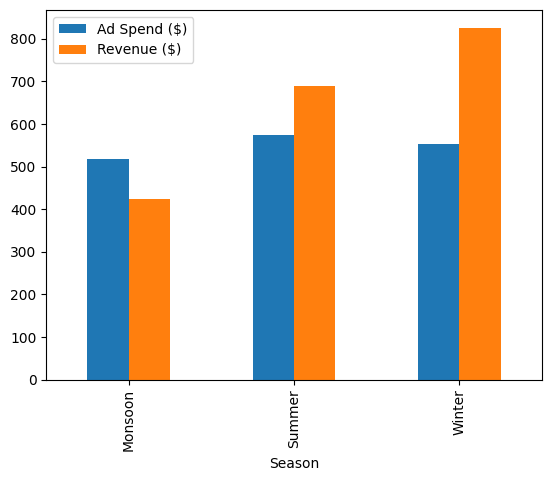

In [7]:
g.plot(kind="bar")

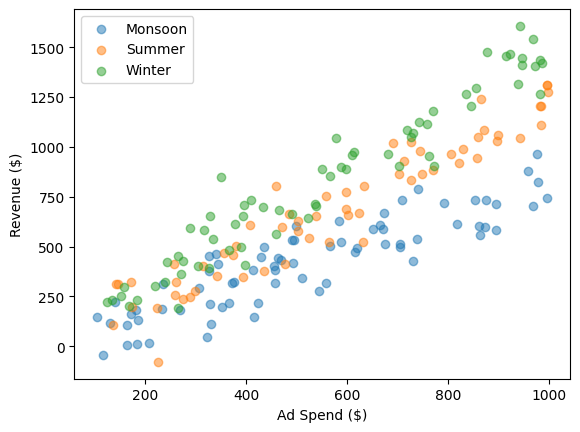

In [8]:
import matplotlib.pyplot as plt
for season, subdf in df.groupby("Season"):
    plt.scatter(subdf["Ad Spend ($)"], subdf["Revenue ($)"], label=season, alpha=0.5)

plt.xlabel("Ad Spend ($)")    
plt.ylabel("Revenue ($)")
plt.legend()
plt.show()

In [10]:
df_encoded=pd.get_dummies(df,columns=["Season"],drop_first=True)
df_encoded.head()

,Ad Spend ($),Revenue ($),Season_Summer,Season_Winter
0,463,440,False,False
1,158,297,False,True
2,328,214,False,False
3,322,48,False,False
4,726,1048,False,True


In [11]:
from sklearn.model_selection import train_test_split

x = df_encoded[["Ad Spend ($)", "Season_Summer", "Season_Winter"]]
y = df_encoded["Revenue ($)"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=10)

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)
model.score(x_test, y_test)

0.8882097000477289

In [14]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(x_train, y_train)
model.score(x_test, y_test)

0.8972778553142061

In [15]:
from sklearn.ensemble import GradientBoostingRegressor

model=GradientBoostingRegressor()
model.fit(x_train, y_train)
model.score(x_test, y_test)

0.9149899654766234

In [18]:
y_pred = model.predict(x_test)
df_eval = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
df_eval.head(5)

,Actual,Predicted
59,605,677.144222
5,1125,1073.575312
20,699,626.698237
198,504,418.202801
52,1310,1134.088133


In [20]:
df_eval['Diff %'] = abs((df_eval['Predicted'] - df_eval['Actual'])*100/df_eval['Actual'])
df_eval.head(5)

,Actual,Predicted,Diff %
59,605,677.144222,11.924665
5,1125,1073.575312,4.571083
20,699,626.698237,10.343600
198,504,418.202801,17.023254
52,1310,1134.088133,13.428387


# Gradient Boosting: Classification

In [2]:
import pandas as pd
df=pd.read_csv(r"..\Datasets\titanic.csv")
df.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500
